In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


In [21]:
data = pd.read_csv("SuperMarket Analysis.csv")
print(data.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.1415   
1  10:29

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [23]:
data.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [24]:
data.describe(include='object')

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,2/7/2019,7:48:00 PM,Ewallet
freq,1,340,340,565,571,178,20,7,345


In [25]:
data.duplicated().sum()

np.int64(0)

In [26]:
data.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [27]:
data.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [28]:
product_sales = data.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
print(product_sales)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64


In [29]:
product_sales.idxmax()

'Food and beverages'

In [30]:
product_sales.max

<bound method Series.max of Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64>

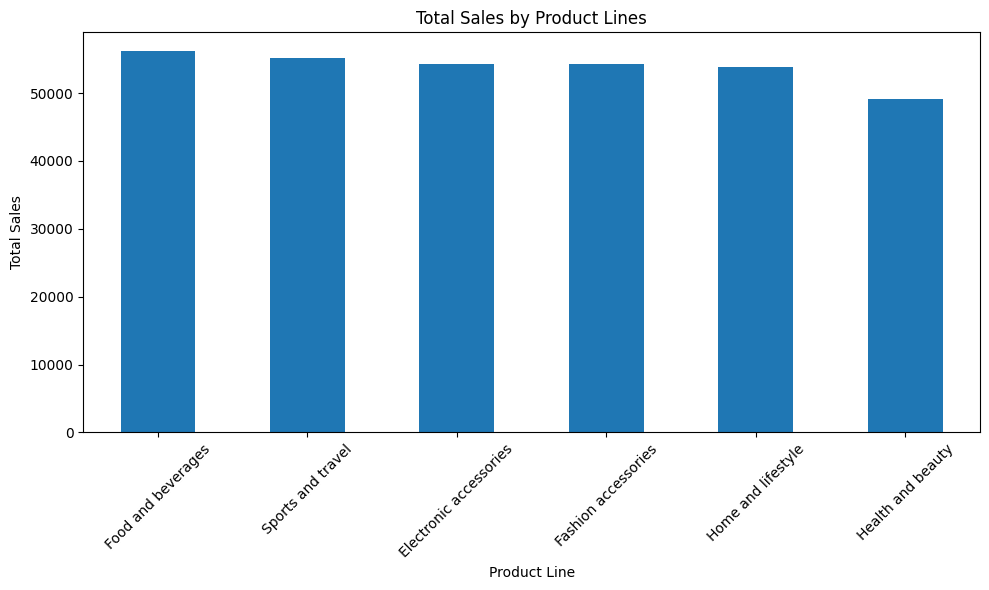

In [31]:
import matplotlib.pyplot as plt
product_sales = data.groupby('Product line')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
product_sales.plot(kind='bar')
plt.title('Total Sales by Product Lines')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
city_sales = data.groupby('City')['Sales'].sum().sort_values(ascending=False)
print(city_sales)


City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64


In [33]:
payment_counts = data['Payment'].value_counts()
print(payment_counts)

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


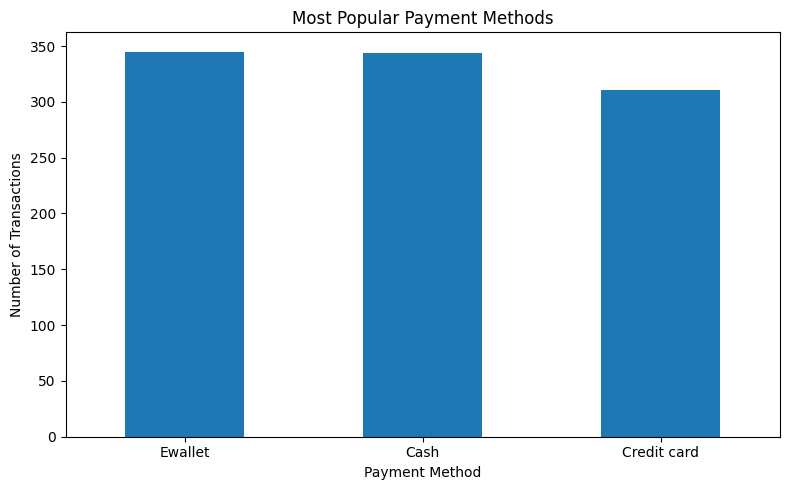

In [34]:
payment_counts = data['Payment'].value_counts()

plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.title('Most Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [35]:
gender_sales = data.groupby('Gender')['Sales'].sum().sort_values(ascending=False)

print(gender_sales)

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


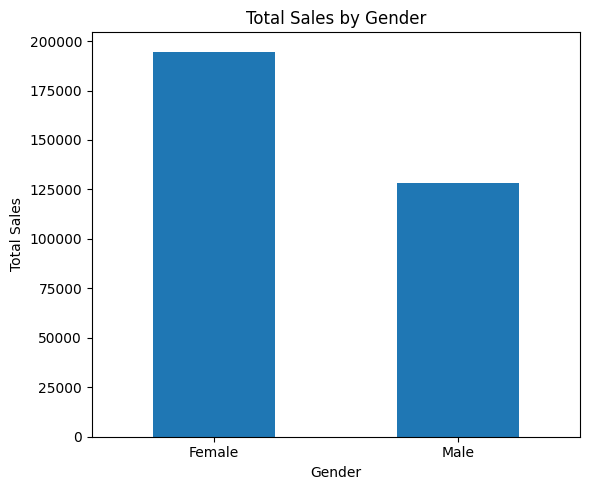

In [36]:
gender_sales = data.groupby('Gender')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [37]:
customer_sales = data.groupby('Customer type')['Sales'].sum().sort_values(ascending=False)

print(customer_sales)

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


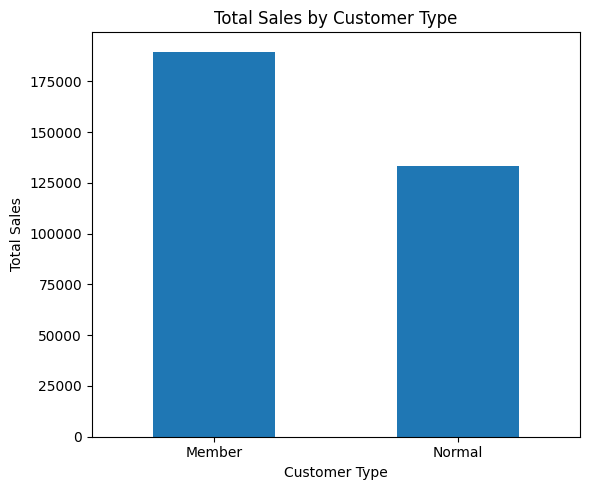

In [38]:
customer_sales = data.groupby('Customer type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 5))

customer_sales.plot(kind='bar')

plt.title('Total Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

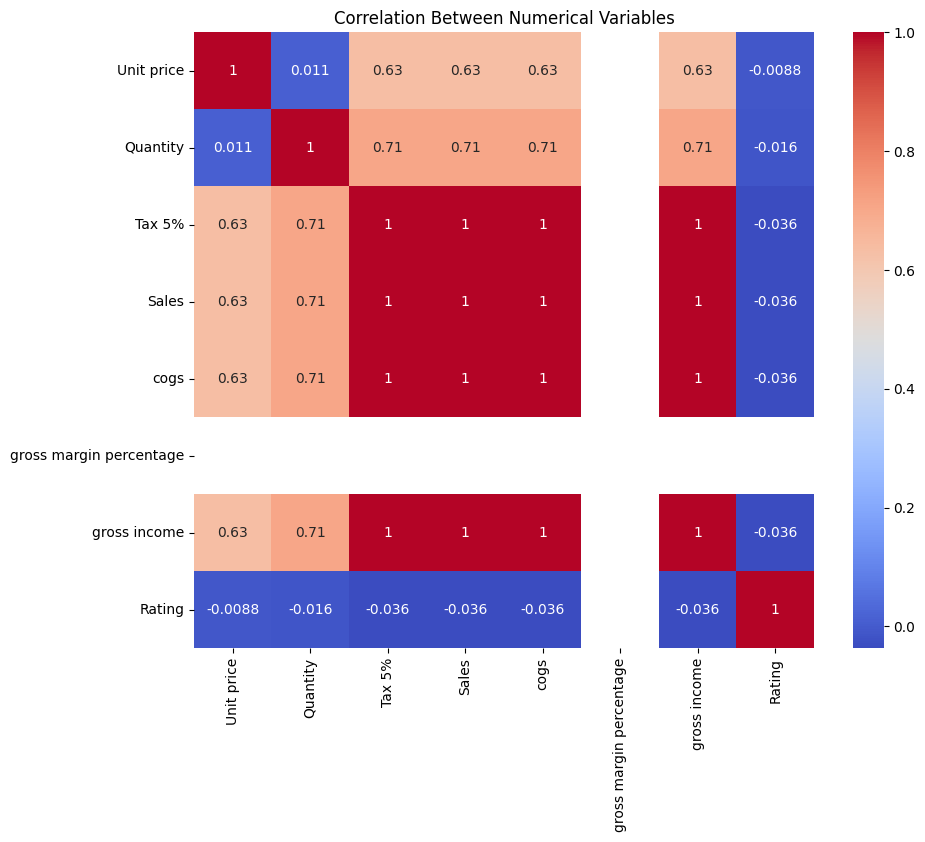

In [39]:
numeric_data = data.select_dtypes(include='number')

correlation = numeric_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Numerical Variables')

plt.show()

First 5 Rows:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905       26.14

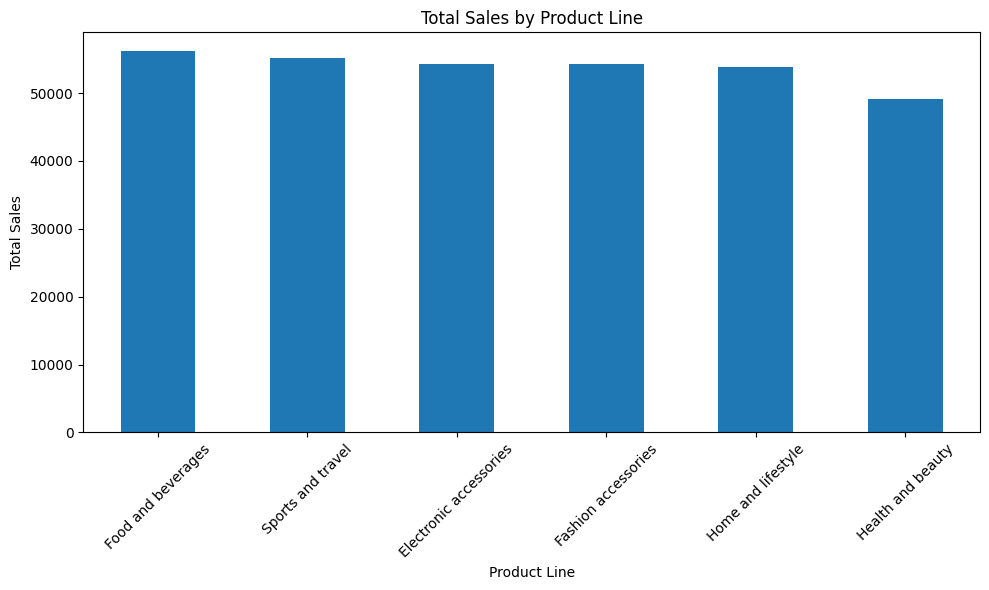


Sales by City:
City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Sales, dtype: float64


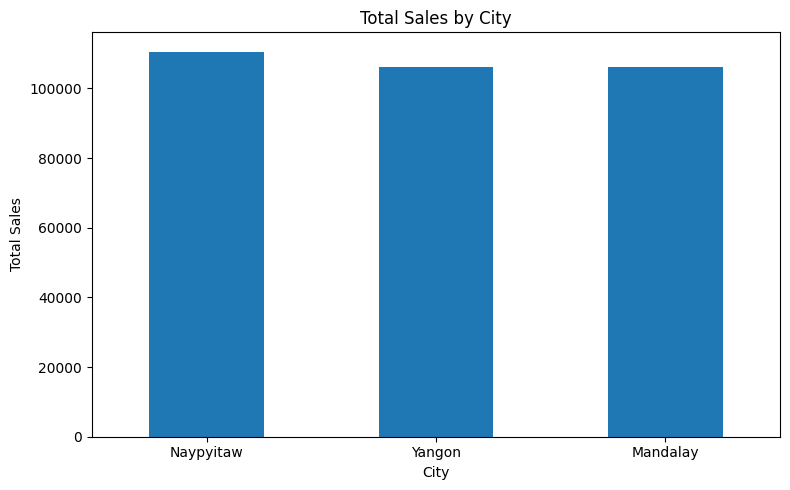


Payment Method Usage:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


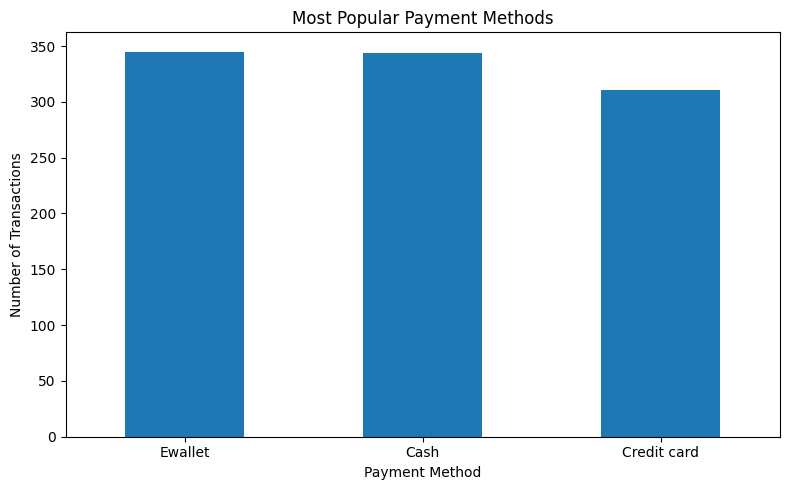


Sales by Gender:
Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64


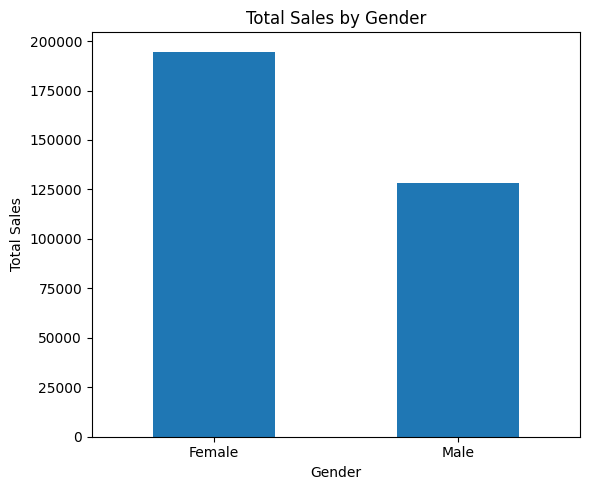


Sales by Customer Type:
Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64


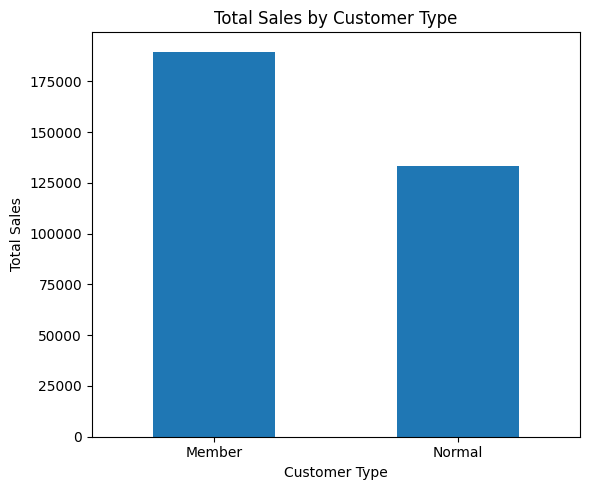

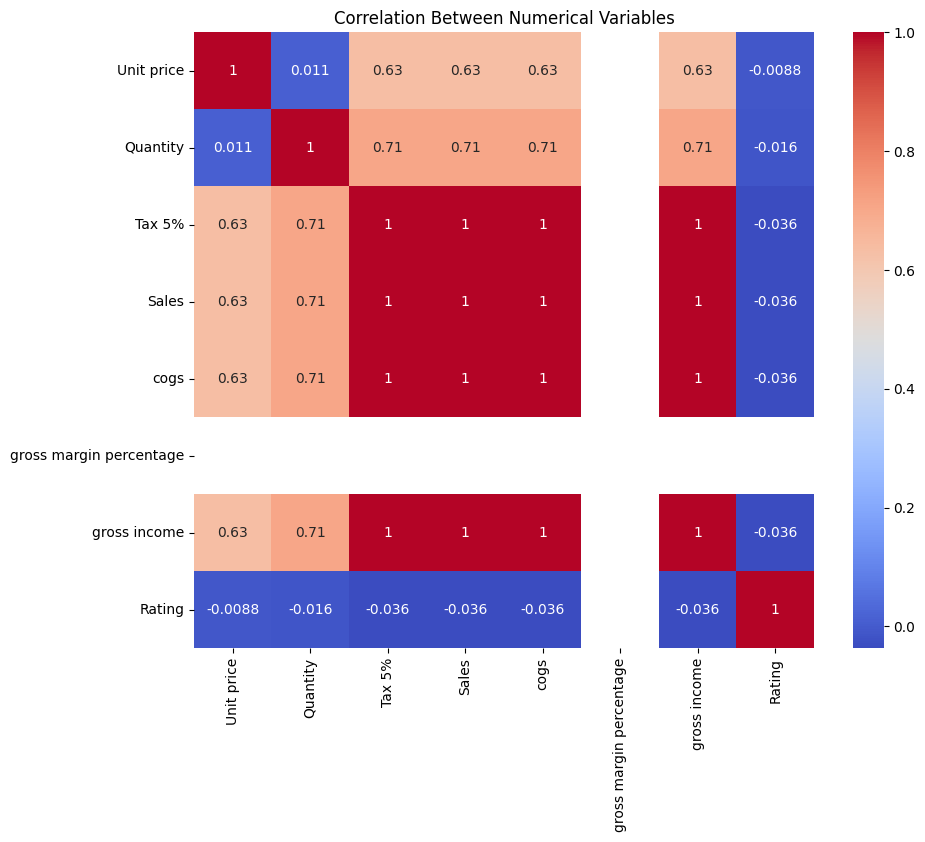

In [40]:
# ==========================================
# CODEALPHA DATA VISUALIZATION PROJECT
# Supermarket Sales Analysis
# ==========================================


# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load Dataset
data = pd.read_csv("SuperMarket Analysis.csv")


# 3. Explore the Dataset
print("First 5 Rows:")
print(data.head())

print("\nDataset Information:")
data.info()

print("\nStatistical Summary:")
print(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())


# 4. Sales by Product Line
product_sales = data.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

print("\nSales by Product Line:")
print(product_sales)

plt.figure(figsize=(10, 6))
product_sales.plot(kind='bar')

plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Sales by City
city_sales = data.groupby('City')['Sales'].sum().sort_values(ascending=False)

print("\nSales by City:")
print(city_sales)

plt.figure(figsize=(8, 5))
city_sales.plot(kind='bar')

plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 6. Payment Method Analysis
payment_counts = data['Payment'].value_counts()

print("\nPayment Method Usage:")
print(payment_counts)

plt.figure(figsize=(8, 5))
payment_counts.plot(kind='bar')

plt.title('Most Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 7. Gender-wise Sales
gender_sales = data.groupby('Gender')['Sales'].sum().sort_values(ascending=False)

print("\nSales by Gender:")
print(gender_sales)

plt.figure(figsize=(6, 5))
gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 8. Customer Type Analysis
customer_sales = data.groupby('Customer type')['Sales'].sum().sort_values(ascending=False)

print("\nSales by Customer Type:")
print(customer_sales)

plt.figure(figsize=(6, 5))
customer_sales.plot(kind='bar')

plt.title('Total Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 9. Correlation Heatmap
numeric_data = data.select_dtypes(include='number')

correlation = numeric_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Numerical Variables')
plt.show()


In [ ]:
print("Supermarket Sales Analysis Project")